# One-Element Test: Drucker-Prager Hyperbolic Model Under Uniaxial Strain

This notebook runs a single-element constitutive benchmark using the `DruckerPragerHyperbolic3D` model from `fenics-constitutive` (main branch).

The goal is to apply a controlled axial strain path and inspect the resulting axial stress response. This kind of test is a compact way to validate material parameters, check nonlinear convergence, and verify that the constitutive update is wired correctly into the solver.

## Model and Boundary-Value Setup

We create a unit cube mesh with one hexahedral element and solve small-strain quasistatics using IncrSmallStrainProblem with a Newton solver.

The constitutive law is the hyperbolic Drucker-Prager model. The parameters $b,b_\mathrm{flow}$ correspond to the slope of the yield surface, meaning they can be derived from the friction angle and the dilitancy angle, respectively. The parameter $h$ controls the hardening rate, and $a_0,d_0$ are the initial yield strength and tip-smoothing parameter, respectively.

Yield function (with pressure sensitivity and tip smoothing):

$$
f(\sigma,\alpha)=\sqrt{J_2+(bd)^2}+bI_1-a
$$

with
$$
I_1=\mathrm{tr}(\sigma),\qquad J_2=\tfrac12\,s:s,\qquad s=\sigma-\tfrac13 I_1\,\mathbf{I}.
$$

Hardening scales a and d with the internal variable alpha (named kappa in the function arguments):

$$
a(\alpha)=\left(1+h\alpha\right)a_0,\qquad d(\alpha)=\left(1+h\alpha\right)d_0.
$$

So the implemented residual is:

$$
f=\sqrt{J_2+\left[b\,d(\alpha)\right]^2}+bI_1-a(\alpha).
$$

Flow direction is associated if b_flow=b, otherwise non-associated:

$$
g_\sigma=
\begin{cases}
\dfrac{\partial f}{\partial \sigma}, & b_{flow}=b,\\
b_{flow}\,\mathbf{I}+\dfrac{\partial f}{\partial J_2}\,s, & b_{flow}\neq b.
\end{cases}
$$

The equivalent plastic-strain measure used by the algorithm is computed from this flow direction:

$$
k=\sqrt{\tfrac23}\,\|g_\sigma\|.
$$

To emulate a uniaxial-strain-type loading state, we prescribe axial displacement in the x direction and constrain one lateral displacement component on each of the planes y=0 and z=0.

In [7]:
import dolfinx as df
import matplotlib.pyplot as plt
import numpy as np
from dolfinx.nls.petsc import NewtonSolver
from mpi4py import MPI

from fenics_constitutive.models.rust_models import DruckerPragerHyperbolic3D
from fenics_constitutive.solver import IncrSmallStrainProblem

# One-element 3D mesh and displacement field with linear shape functions
mesh = df.mesh.create_unit_cube(MPI.COMM_WORLD, 1, 1, 1)
V = df.fem.functionspace(mesh, ("CG", 1, (3,)))
u = df.fem.Function(V, name="u")

# Convert (E, nu) to (mu, kappa), then add Drucker-Prager-Hyperbolic parameters.
E = 3.0e4
nu = 0.2
mu = E / (2.0 * (1.0 + nu))
kappa = E / (3.0 * (1.0 - 2.0 * nu))

matparam = {
    "mu": np.array([mu]),
    "kappa": np.array([kappa]),
    "a": np.array([150.0]),
    "b": np.array([0.08]),
    "d": np.array([50.0]), # tip smoothing, not sure if the parameter value makes sense
    "h": np.array([0.0]), # no hardening
    "b_flow": np.array([0.04]), # nonassociative flow rule
}
law = DruckerPragerHyperbolic3D(matparam)

# Boundary markers
def left(x):
    return np.isclose(x[0], 0.0)


def right(x):
    return np.isclose(x[0], 1.0)


def y0(x):
    return np.isclose(x[1], 0.0)


def z0(x):
    return np.isclose(x[2], 0.0)


tdim = mesh.topology.dim
fdim = tdim - 1

# search for the objects inside the mesh that match the boundary markers,
#  and get the corresponding facet indices
left_facets = df.mesh.locate_entities_boundary(mesh, fdim, left)
right_facets = df.mesh.locate_entities_boundary(mesh, fdim, right)
y0_facets = df.mesh.locate_entities_boundary(mesh, fdim, y0)
z0_facets = df.mesh.locate_entities_boundary(mesh, fdim, z0)

zero = df.fem.Constant(mesh, 0.0)
disp_x = df.fem.Constant(mesh, 0.0)

# Uniaxial strain-like setup: prescribe epsilon_xx through u_x and constrain one lateral plane each.
fix_ux_left = df.fem.dirichletbc(
    zero,
    df.fem.locate_dofs_topological(V.sub(0), fdim, left_facets), # locate degrees in x direction
    V.sub(0),# restrain in x direction only
)
move_ux_right = df.fem.dirichletbc(
    disp_x,
    df.fem.locate_dofs_topological(V.sub(0), fdim, right_facets),
    V.sub(0),
)
fix_uy = df.fem.dirichletbc(
    zero,
    df.fem.locate_dofs_topological(V.sub(1), fdim, y0_facets),
    V.sub(1),
)
fix_uz = df.fem.dirichletbc(
    zero,
    df.fem.locate_dofs_topological(V.sub(2), fdim, z0_facets),
    V.sub(2),
)

dirichlet = [fix_ux_left, move_ux_right, fix_uy, fix_uz]

problem = IncrSmallStrainProblem(law, u, dirichlet, q_degree=1)
solver = NewtonSolver(MPI.COMM_WORLD, problem)

The model has the following internal variables:

In [8]:
law.history_dim

{'history': 7}

which consists of the accumulated plastic strain $\alpha$ and the full plastic strain vector $\varepsilon^p$ in that order.

## Incremental Loading Experiment

The next code cell performs displacement-controlled loading in `n_steps` increments from zero to `max_disp`. At each increment, we:

1. Update the prescribed boundary displacement
2. Solve the nonlinear equilibrium problem
3. Commit the constitutive state (`problem.update()`)
4. Store the axial stress component `sigma_xx`

For interpretation, the plot also includes a purely elastic reference line with slope `C11 = kappa + 4*mu/3`.

If plasticity activates, the Drucker-Prager response departs from that line and typically shows reduced tangent stiffness compared with the elastic predictor.

All increments converged: True
Average Newton iterations: 4.00
Final sigma_xx: 228.096


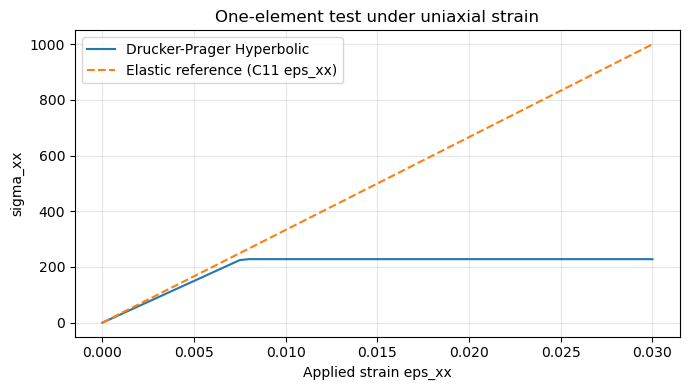

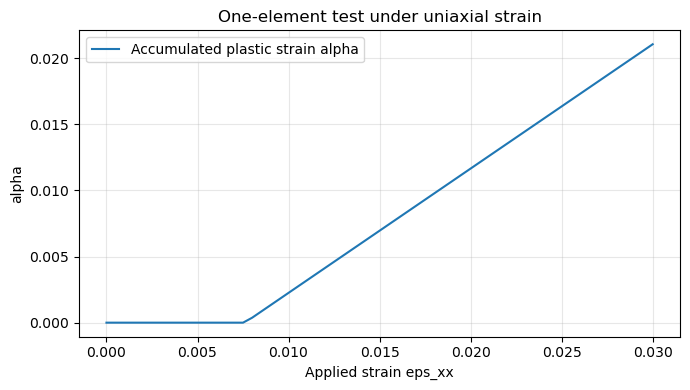

In [9]:
n_steps = 60
max_disp = 0.03
displacements = np.linspace(0.0, max_disp, n_steps + 1)
sigma_xx = np.zeros_like(displacements)
alpha = np.zeros_like(displacements)
newton_iters = np.zeros(n_steps, dtype=np.int32)
all_converged = True

for i, ux in enumerate(displacements[1:], start=1):
    disp_x.value = ux
    niter, converged = solver.solve(u)
    problem.update()

    all_converged = all_converged and converged
    newton_iters[i - 1] = niter

    # stress layout is [s11, s22, s33, s12, s13, s23] per integration point
    stress_values = problem.stress_0.x.array
    sigma_xx[i] = stress_values[0]
    alpha[i] = problem._history_0[0]["history"].x.array[0] # extract alpha from the history variable

if MPI.COMM_WORLD.rank == 0:
    print(f"All increments converged: {all_converged}")
    print(f"Average Newton iterations: {newton_iters.mean():.2f}")
    print(f"Final sigma_xx: {sigma_xx[-1]:.3f}")

    elastic_c11 = kappa + 4.0 * mu / 3.0
    eps_xx = displacements
    sigma_elastic_ref = elastic_c11 * eps_xx

    plt.figure(figsize=(7, 4))
    plt.plot(eps_xx, sigma_xx, label="Drucker-Prager Hyperbolic")
    plt.plot(eps_xx, sigma_elastic_ref, "--", label="Elastic reference (C11 eps_xx)")
    plt.xlabel("Applied strain eps_xx")
    plt.ylabel("sigma_xx")
    plt.title("One-element test under uniaxial strain")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(eps_xx, alpha, label="Accumulated plastic strain alpha")
    plt.xlabel("Applied strain eps_xx")
    plt.ylabel("alpha")
    plt.title("One-element test under uniaxial strain")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
